### K-means k-평균-비지도학습-군집(cluster)
- step1. 초기 중심점 설정(centroid)
- step2. 데이터할당(Assignment)
- step3. 중심점 업데이트 (Update)

In [ ]:
import numpy as np
fruits = np.load('D:/0python_SNC/15pandas/pandas-data-analysis-main/part7/data/fruits_300.npy')
fruits.shape #이미지 100 X 100 #3차원 데이터.. 
#(300, 100, 100) 이미지는 이렇게 나옴.
# 300 => batch 300개가 100X100으로 있다...?

(300, 100, 100)

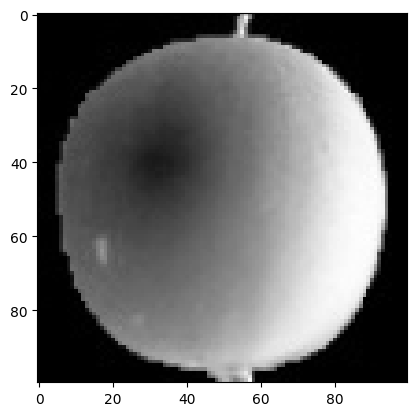

In [17]:
import matplotlib.pyplot as plt
plt.imshow(fruits[0], cmap='gray') #fruits[200] 여기 숫자 바꾸면 과일 모양 나옴..
plt.show()

In [ ]:
fruits[150]
#100X100 이미지... 100개가 각각의 픽셀로... 숫자가 작을수록 흑백

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(100, 100), dtype=uint8)

In [ ]:
fruits[0,0,:]
#가로세로 200개 중에서 첫번째 데이터만..? 하기 노란 박스 부분을 보여줌

array([  1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   2,   1,   2,   2,   2,   2,   2,   2,   1,   1,
         1,   1,   1,   1,   1,   1,   2,   3,   2,   1,   2,   1,   1,
         1,   1,   2,   1,   3,   2,   1,   3,   1,   4,   1,   2,   5,
         5,   5,  19, 148, 192, 117,  28,   1,   1,   2,   1,   4,   1,
         1,   3,   1,   1,   1,   1,   1,   2,   2,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1], dtype=uint8)


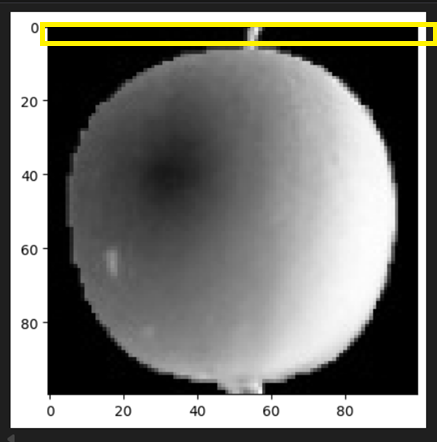

In [ ]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, random_state=42)
fruits.ndim  #3차원
#sklearn 계열은 학습 데이터는 2차원이어야함. ==> #차원 변경해보기 example /셀보기
'''
#차원 변경해보기 example

temp = np.array([ [1,2], [3,4] ])
print(temp.shape)
print(temp.ndim)


temp.reshape(1,4)
temp.reshape(4,1)
temp.reshape(-1,1)  #-1을 입력하면 알아서 변경됨. 뒤에가 1 또는 앞이 1일때
# temp.reshape(1,-1)
'''

f2d=fruits.reshape(300,-1)
f2d.ndim
km.fit(f2d)
km.labels_  #출력결과:학습한 데이터를 클러스터0,1,2로 분류된 것을 확인
km.cluster_centers_
km.cluster_centers_.shape  #(3, 10000) => 중심좌표가 3개



(3, 10000)

In [33]:
km.labels_[:10]

array([2, 2, 2, 2, 2, 0, 2, 2, 2, 2], dtype=int32)

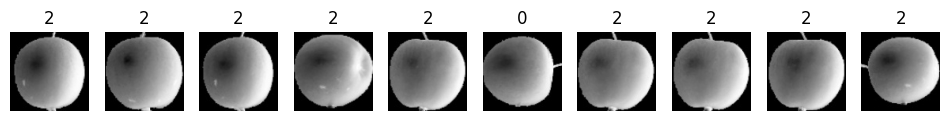

In [ ]:
#상기 클러스터 분류된 이미지 확인해보기
import matplotlib.pyplot as plt
plt.figure(figsize=(12,10))
for i in range(10):
    plt.subplot(1,10,1+i)
    plt.axis('off')
    plt.imshow(fruits[i], cmap='gray')
    plt.title(km.labels_[i])
plt.show()

In [ ]:
fruits [km.labels_== 2].shape
# 출력 해석 (90, 100, 100) : 사과 이미지 가진게 90개다... ==> 클래스 2

(90, 100, 100)

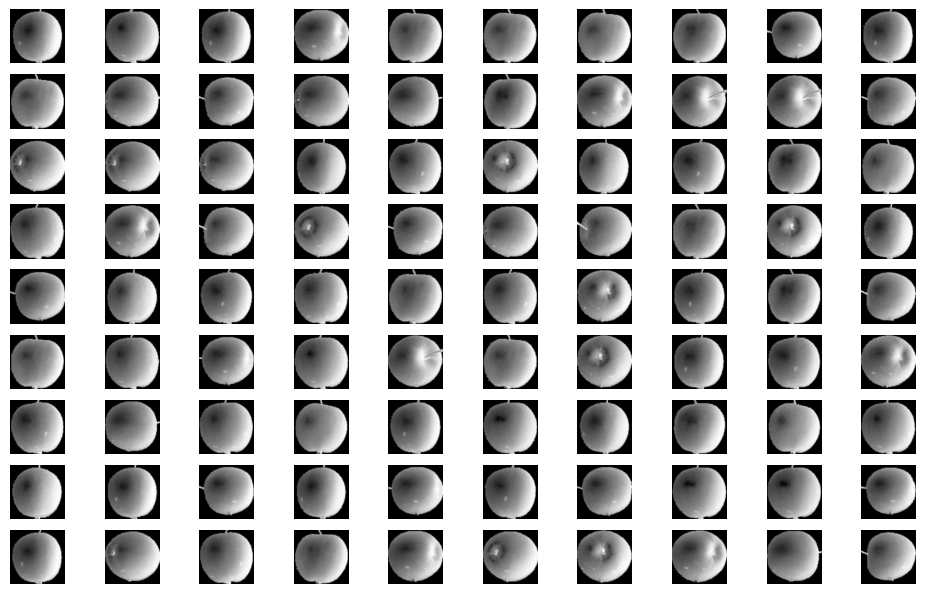

In [54]:
#클래스2 이미지
plt.figure(figsize=(12,10))
for i,apple in enumerate(fruits[km.labels_ == 2]): 
    plt.subplot(12,10,1+i)
    plt.axis('off')
    plt.imshow(apple, cmap='gray')

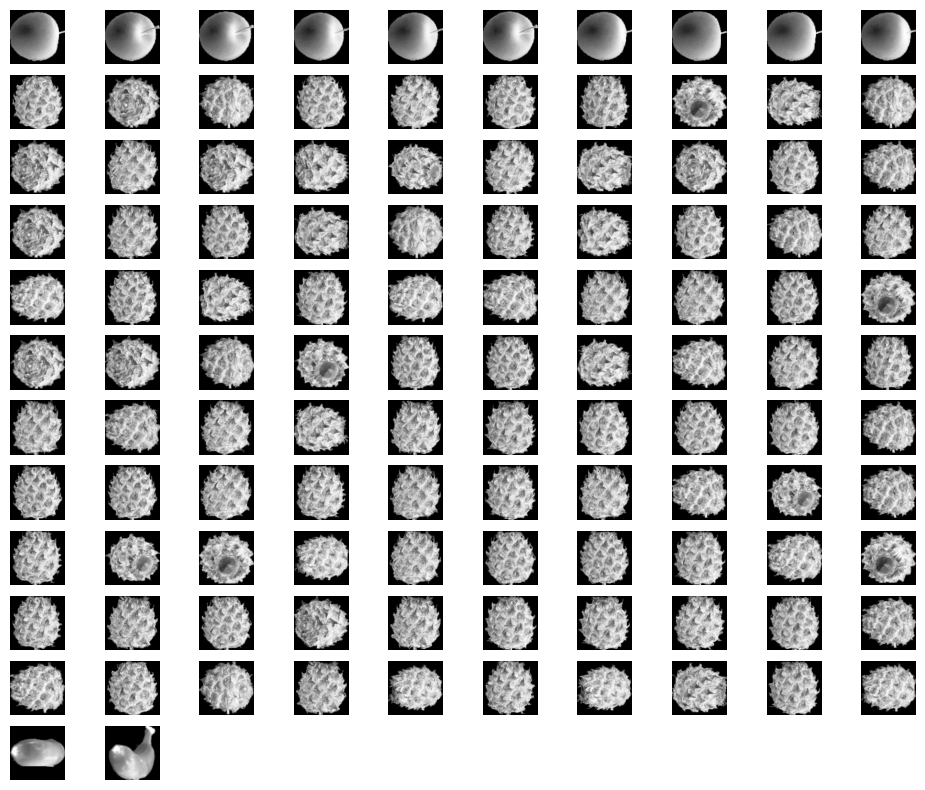

In [59]:
#클래스0 이미지
plt.figure(figsize=(12,10))
for i,apple in enumerate(fruits[km.labels_ ==0]): 
    plt.subplot(12,10,1+i)
    plt.axis('off')
    plt.imshow(apple, cmap='gray')

#    plt.imshow(fruits[i], cmap='gray')

In [72]:
# K-Means에서 “몇 개로 나누는 게 제일 좋은가?” 를 정하는 핵심
# 최적의 k 값 찾기: 엘보우(elbow) 방법
# 클러스터의 응집도 측정하는 성능지표 / 각 데이터 포인터가 자신이 속한 클러스터의 중심과 얼마나 가까운지를 나타내는 총 거리합
# 클러스터가 많을수록 줄어드는 특징
# 그래프에서 k가 증가하면서 ineritia_ 감소폭이 급격히 줄어드는 지점이 적절한 k (이게 낮다고해서 무조건 좋은건 아님. 클러스터 많아지면 과적합될수도?)
# 거리기반 이므로 이상치에 민감.
# 스케일링 필수 
#km.inertia_ #그룹 안에서 데이터들이 중심과 얼마나 모여있는지(응집) 나타내는 숫자


# 만약 3개 그룹으로 나눴는데,
# 각 그룹의 중심에서 데이터들이 멀리 퍼져 있다면 → inertia 값이 크다
# 각 그룹 안의 데이터들이 중심 근처에 딱딱 모여 있다면 → inertia 값이 작다
# 👉 그래서 inertia는 작을수록 좋은 모델처럼 보이죠.


# 그룹 수(k)를 늘리면…
# 데이터가 더 잘게 쪼개져서 각 그룹 안 데이터들이 더 가까워지니까 → inertia 값이 계속 줄어요.
# 하지만 너무 많이 나누면 의미 없는 과적합(overfitting) 이 돼요 😵‍💫
# (예: 사람 10명을 “10개의 그룹”으로 나누면 당연히 완벽히 가까움 → 하지만 쓸모 없음)

# 💪 그래서 나온 게 엘보우 방법 
# 여러 개의 k 값을 시도해 보고,
# 각각의 inertia_를 구해서 그래프로 그리면 이런 모양이 나와요 👇
# 📍 그래프가 급격히 꺾이는 부분 (팔꿈치 모양처럼 보이는 곳)이 “적절한 k” 값이에요.
# 그래서 엘보우(elbow) 라고 불러요 💪

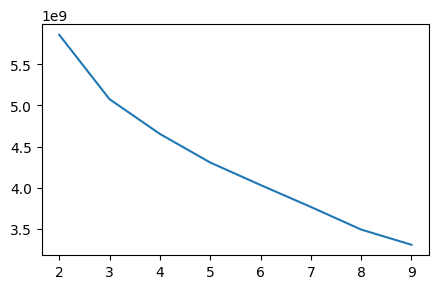

In [71]:
inertia = []
plt.figure(figsize=(5,3))
for k in range(2,10):
    km=KMeans(n_clusters=k, random_state=42)
    km.fit(f2d)
    inertia.append(km.inertia_)
plt.plot(range(2,10), inertia)
